## Titanic Data set Kaggle.com

The excercise takes a sample of 891 records from the Titanic dataset. The original dataset is comprised of 2,240 passenger records. The Titanic is a famous ship that sank in 1912 on its way from Southampton, England to New York. On board more than 1500 passengers did not survived. 

The challenge of the excercise is to develop a predictive model to predict the chance of survival based on known passenger ticket information, such as gender, age and passenger class and predict whether they would survive or not (hence a binary outcome of yes or no (0 or 1).

The original data: train.csv can be found in the same location as this file on Gitbhub).

In this excercise, I create 5 different machine learning models to predict passenger survival:
1. Naive Bayes
2. Logistical Regression
3. Decision Tree
4. Random Forests
5. XG Boost

I have developed this file with the flow designed as a template to use for similar binary outcome predictive models.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import OneHotEncoder
from toolz import pipe
from sklearn import svm

pd.set_option('display.precision', 2)

df = pd.read_csv(r"C:\Users\Admin\Documents\GitHub\Google Course\Kaggle Titanic Competition\train.csv")
df.rename(columns = {'Sex': 'Gender'}, inplace = True)
df['Source'] = "train"

### CTRL + / to has multiple lines

In [3]:
df.shape

(891, 13)

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Source
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,train
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.28,C85,C,train
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S,train
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.10,C123,S,train
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S,train


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Gender       891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  Source       891 non-null    object 
dtypes: float64(2), int64(5), object(6)
memory usage: 90.6+ KB


In [7]:
#Feature engineering: Functon to create a new feature extracting title from the name field.

def extract_title(name):
    if 'Mr' in name:
        return 'Mr'
    elif 'Mrs' in name:
        return 'Mrs'
    elif 'Miss' in name:
        return 'Miss'
    elif 'Master' in name:
        return 'Master'
    elif 'Rev' in name:
        return 'Rev'
    elif 'Dr' in name:
        return 'Dr'
    else:
        return 'Unknown'

def add_title_column(df_subset):
    df_subset['Title'] = df_subset['Name'].apply(extract_title)
    return df_subset

In [8]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Gender', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Source'],
      dtype='object')

In [9]:
#Feature engineering: functions to create additional features..

def fare_band(df_subset):
        df_subset['Fare_Band'] = pd.qcut(df.Fare, q=5)
        return df_subset


def cabin_code(df_subset):
        df_subset['Cabin_Code'] = df_subset['Cabin'].str[:1]
        df['Cabin_Code'].fillna('Z', inplace=True)
        return df_subset

def cabin_survival(df_subset):
    mask = (~df_subset['Cabin_Code'].isna())
    cabin = df_subset[mask]
    cabin = cabin[['Cabin_Code', 'Survived']]
    cabin_mean = cabin.groupby(['Cabin_Code']).mean()
    cabin_mean.rename(columns = {'Survived': 'Cabin_Survival_Rate'}, inplace=True)
    df_cabin = pd.merge(df_subset, cabin_mean, on='Cabin_Code', how="left")
    return df_cabin

def age(df_subset):
    age_df = df[['Age', 'Pclass']]
    age_df = age_df.groupby('Pclass').mean()[['Age']]
    age_df = age_df.rename(columns = {'Age': 'Age_mean'})    
    age_merge = pd.merge(df_subset, age_df, on='Pclass', how="left")
    return age_merge

def surname(df_subset):
    # Split the 'Name' column on commas and take the first part
    df_subset['family'] = df_subset['Name'].str.split(',').str[0]
    return df_subset

def family_count(df_subset):
        family = df_subset[['family']].value_counts().reset_index().sort_values(by='count', ascending = False)
        family.groupby('family').agg({'count': ['count']})
        family.columns = ["family", "family_count"]
        family_merge = pd.merge(df_subset, family, on='family', how="left")
        return family_merge


In [10]:
#One hot encoding

def one_hot_encoding(df_subset):
        df_subset = pd.get_dummies(df_subset, columns=['Gender', 'Embarked'])
        return df_subset

In [11]:
#pipeline: run the dataframe through the various functions to create all the additonal columns in one step.

df =  pipe(df, cabin_code, cabin_survival, age, surname, family_count, add_title_column, one_hot_encoding)

In [12]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Source', 'Cabin_Code',
       'Cabin_Survival_Rate', 'Age_mean', 'family', 'family_count', 'Title',
       'Gender_female', 'Gender_male', 'Embarked_C', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')

### Observations

891 rows in the dataset with 15 Columns.

'Survived' will be the dependent variable (Binary: 0 or 1), this is what we will be trying to predict.

3 columns have null values: 'Age', 'Cabin' and 'Embarked'. We need to fill them.
There are 6 string columns: 'Name', 'Ticket', 'Cabin', 'Embarked', 'Source' and 'Gender'
'Fare' has a mean of 32 and max of 512 suggesting skew in data and outliers.

In [13]:
#pd.cut(df.Fare, bins=10, right=True).head(20)
df['Fare_Band'] = pd.qcut(df.Fare, q=5).head(7)

### Bar Graph of overall survivor rate

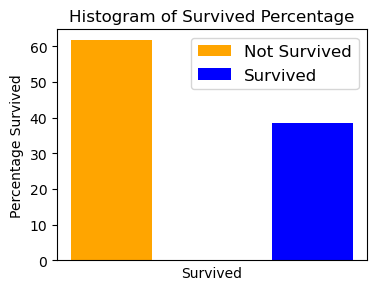

In [14]:
survived_percentage = df['Survived'].value_counts(normalize=True) * 100

# Plotting the histogram with switched axes using plt.bar()
plt.figure(figsize=(4, 3))
plt.bar(survived_percentage.index, survived_percentage.values, color=['orange', 'blue'], width=0.4)
# Adding labels and title
plt.xlabel('Survived')
plt.ylabel('Percentage Survived')
plt.title('Histogram of Survived Percentage')
plt.xticks(ticks=[])

# Adding legend using the handles returned by plt.bar()
bars = plt.bar(survived_percentage.index, survived_percentage.values, color=['orange', 'blue'], width=0.4)
plt.legend(handles=bars, labels=['Not Survived', 'Survived'], loc='best', fontsize=12)

In [15]:
df['Survived'].value_counts(normalize=True)

Survived
0    0.62
1    0.38
Name: proportion, dtype: float64

### Observations:
62% did not survive
38% survived

## Histograms for Categorical Features

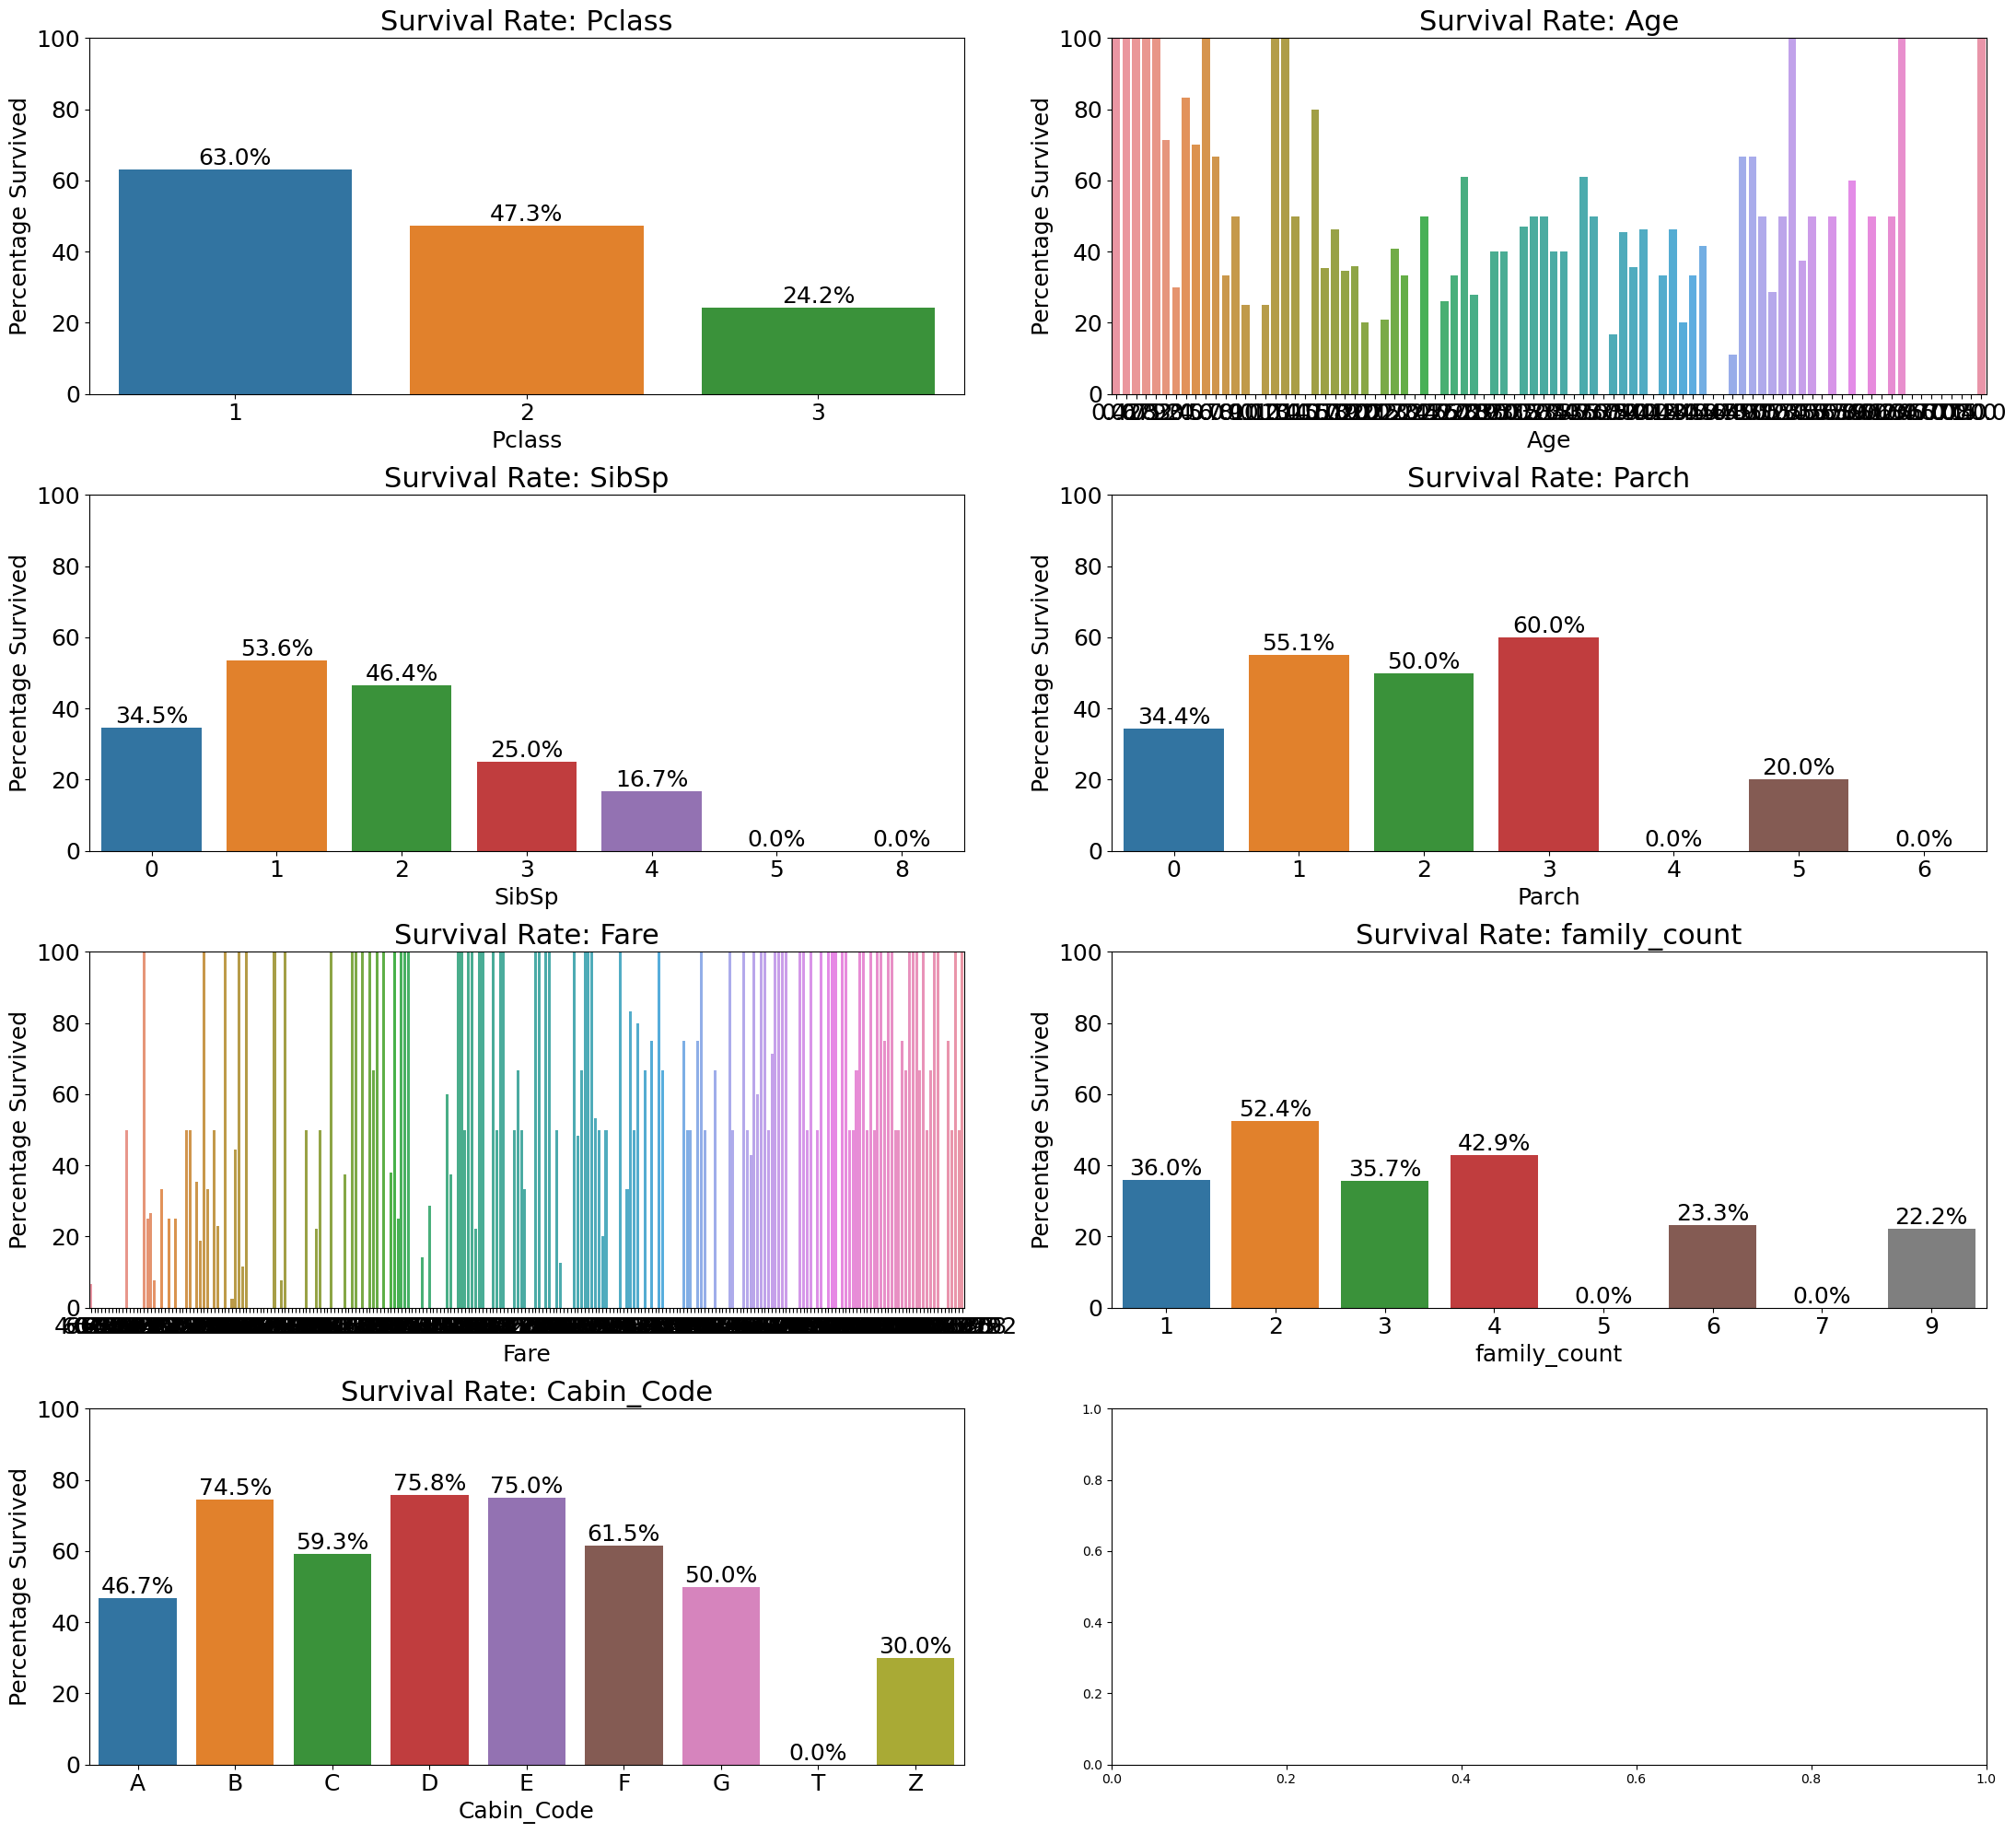

In [16]:
# Function to plot histograms
def plot(plot_list):
    list_len = int(len(plot_list)/2+1)
    fig, ax = plt.subplots(list_len, 2, figsize=(22, 20))
    ax = ax.ravel()  # Flatten the 2x2 subplot array
    
    
    for i in range(len(plot_list)):
        series_name = plot_list[i]
        survived = df['Survived']
        unique_values = df[series_name].nunique()
        percentage_survived = df.groupby(series_name)['Survived'].mean() * 100
            
        # Plotting using seaborn barplot
        sns.barplot(x=percentage_survived.index, y=percentage_survived.values, ax=ax[i])
        
        #ax[i].hist(df[series_name].dropna(),  edgecolor='black', hue = Survived)
        ax[i].set_ylabel('Percentage Survived', fontsize=18)
        ax[i].set_xlabel(series_name, fontsize=18)
        ax[i].set_title(f'Survival Rate: {series_name}', fontsize=22)
        #plt.yticks(fontsize=20)
        ax[i].tick_params(axis='x', labelsize=18)  
        ax[i].tick_params(axis='y', labelsize=18)  
        ax[i].set_ylim(0, 100)  # Set y-axis limit to ensure percentage is within 0-100
        
        # Annotate percentages on top of each bar
        if unique_values < 20:
            for bar, percent in zip(ax[i].patches, percentage_survived.values):
                ax[i].annotate(f'{percent:.1f}%', 
                           (bar.get_x() + bar.get_width() / 2, bar.get_height()), 
                           ha='center', va='bottom', fontsize=18, color='black')
        
        
    plt.tight_layout()
    plt.show()
plot_list = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'family_count', 'Cabin_Code']

plot(plot_list)

## Observations
Pclass: class 1 63% vs. 24% in class 3. Significant differences in survial rate

Age Range: Lower age ranges associated with higher survival rates.

Sibsp (has sibling or spouse). value of 1 having highest survival rate of 53.6%. different SibSp associated with different rates.

Parch (has parent or child) associated with lower survival rate of 34%. 

Fare: higher survival rates associated with higher fares. lowest fares associated with lowest survival rates.

Embarked (S: Southampton, C: Cherbourg and Q: Queensland (Ireleand) associated with different survival rates. This may be just due to associated economic status (Pclass).

Gender: Signficant difference in Gender survial rates: Female survial rate: 74%, males: 19%


# Boxplots for numeric features

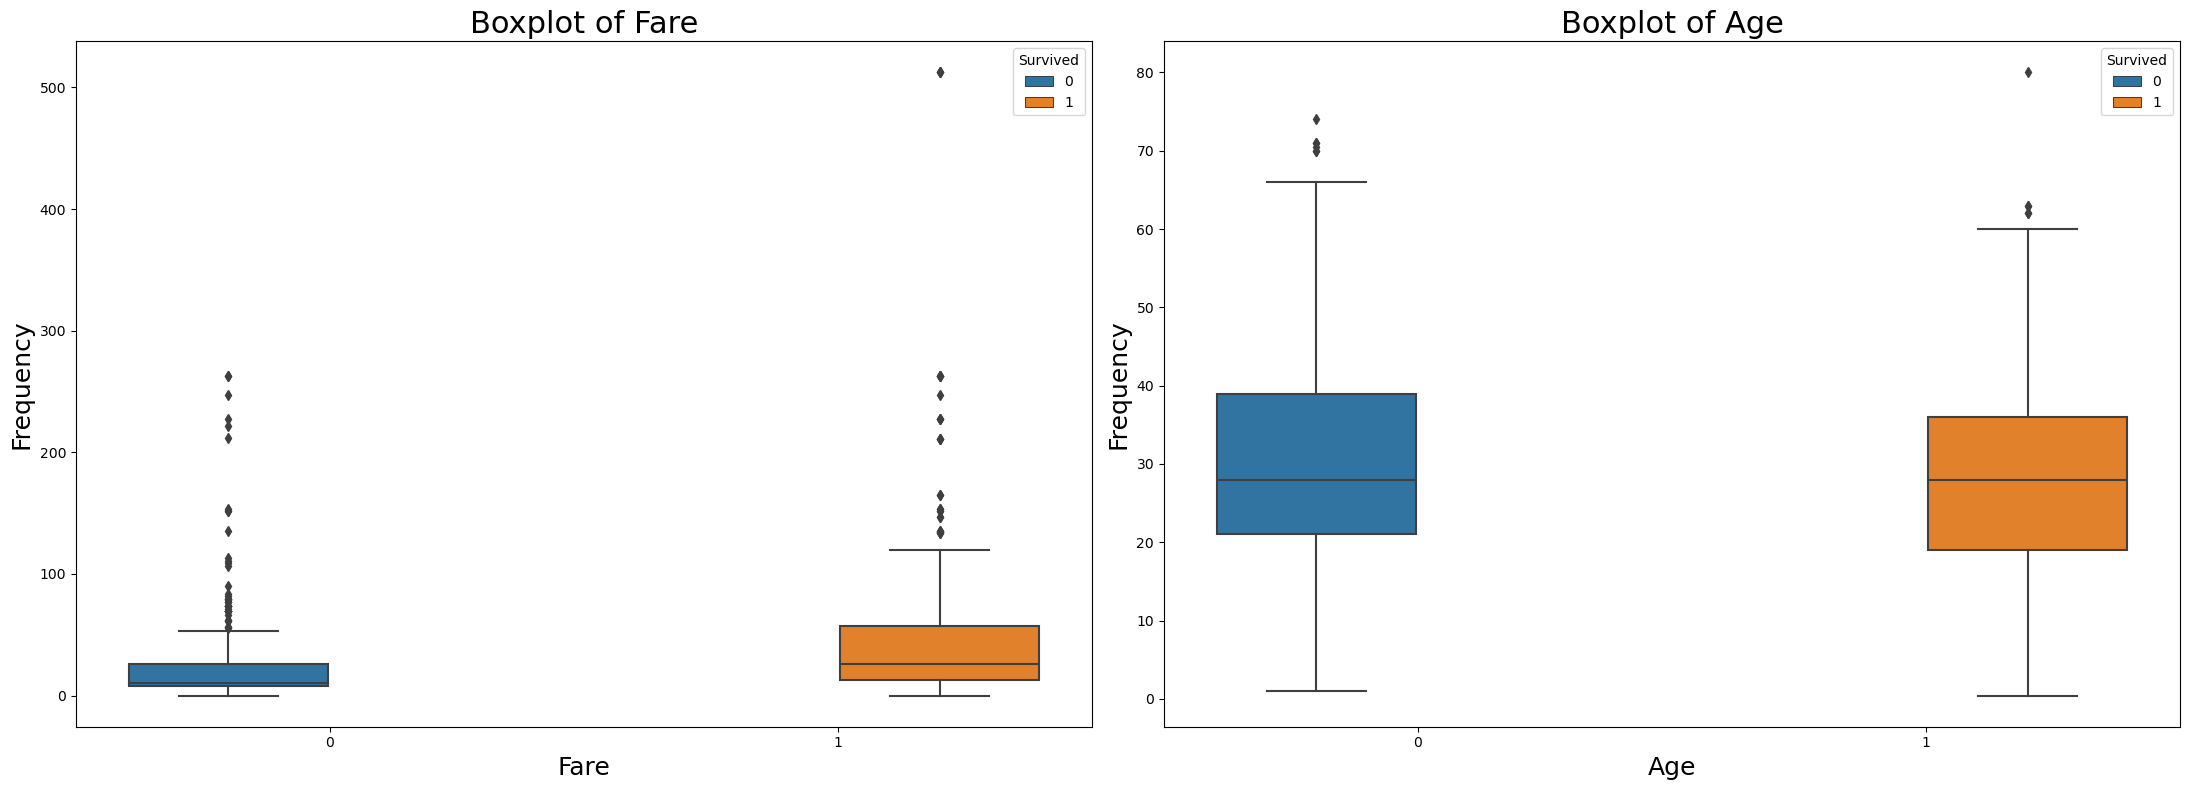

In [17]:
# Function to plot boxplots
def plot(plot_list):
    list_len = int(len(plot_list)/2+1)
    fig, ax = plt.subplots(1, 2, figsize=(22, 8))
    ax = ax.ravel()  # Flatten the 2x2 subplot array
    
    for i in range(len(plot_list)):
        series_name = plot_list[i]
        survived = df['Survived']
        sns.boxplot(data = df, x = survived, y=df[series_name], hue = 'Survived', ax=ax[i]);
        ax[i].set_ylabel('Frequency', fontsize=18)
        ax[i].set_xlabel(series_name, fontsize=18)
        ax[i].set_title(f'Boxplot of {series_name}', fontsize=22)
        #plt.yticks(fontsize=20)
       # ax[i].tick_params(axis='x', labelsize=18)  
       # ax[i].tick_params(axis='y', labelsize=18)  
    plt.tight_layout()
    plt.show()
plot_list = [ 'Fare', 'Age']

plot(plot_list)

## Observations

Noticable outliers in the 'Fare feature'. Data skewed signficantly to lower amounts shown by median at bottom of IQR
Median Fare of survied higher than non-survivors. Signficant numbers of outliers in heavily skewed down non-survivors.

Age: Surviors Interquartile range lower than non-surviors suggesting age is a factor in survival. A few outliers.

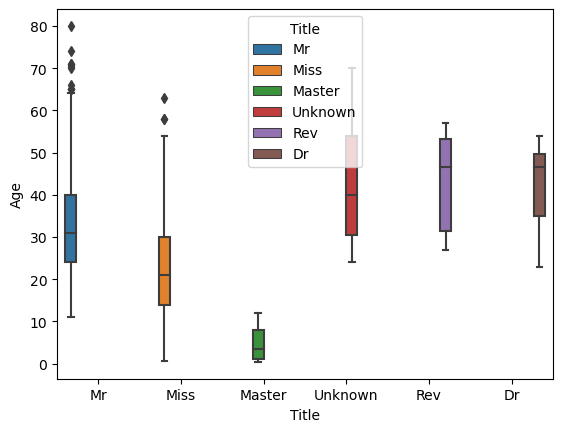

In [18]:
plt.figure()
g = sns.boxplot(
    data = df,
    x = 'Title',
    y = 'Age',
    hue = 'Title');

#g.set_title('test');
#plt.xticks(rotation=90)
for i in g.containers:
    g.bar_label(i,)

plt.show()


##  Imputing Age and Single

In [19]:
# Master Age impute
mask = (df['Title'] == 'Master')
master = df[mask]
master_mean_age = np.mean(master['Age'])

df['Age_Imputed'] = df['Age']
#Null Master = master_mean
df.loc[(df['Title'] == 'Master') & (df['Age'].isna()), 'Age_Imputed'] = master_mean_age

#Null Mr = 30
df.loc[((df['Age'].isna()) & (df['Title'] == 'Mr')), 'Age_Imputed'] = 30

#Miss no SibSP or Parch
df.loc[( (df['Age'].isna()) & (df['Title'] == 'Miss') & (df['Parch'] == 0) ), 'Age_Imputed'] = 30

#Miss with SibSP or Parch
df.loc[( (df['Age'].isna()) & (df['Title'] == 'Miss') & (df['Parch'] > 0) ), 'Age_Imputed'] = 10

#Miss with SibSP or Parch
df.loc[( (df['Age'].isna()) & (df['Title'] == 'Dr') ), 'Age_Imputed'] = 40

#Single if no SibSp or Parch
df.loc[( (df['Parch'] == 0) & (df['SibSp'] == 0) ), 'Single'] = 1
df.loc[df['Single'] != 1, 'Single'] = 0

#Child
df.loc[df['Age_Imputed'] < 16, 'Child'] = 1
df.loc[df['Child'] != 1, 'Child'] = 0

#Old Man
df.loc[((df['Age_Imputed'] > 40) & (df['Gender_male'] == 1)), 'Old_Man'] = 1
df.loc[df['Old_Man'] != 1, 'Old_Man'] = 0

#mask2 = df['Age_Imputed'].isna()
#df[mask2] 
df['Single'].value_counts()

Single
1.0    537
0.0    354
Name: count, dtype: int64

## Correlation

In [20]:
df_all = df[['Survived', 'Age', 'SibSp', 'Parch', 'Fare', 'Pclass', 'family_count']]

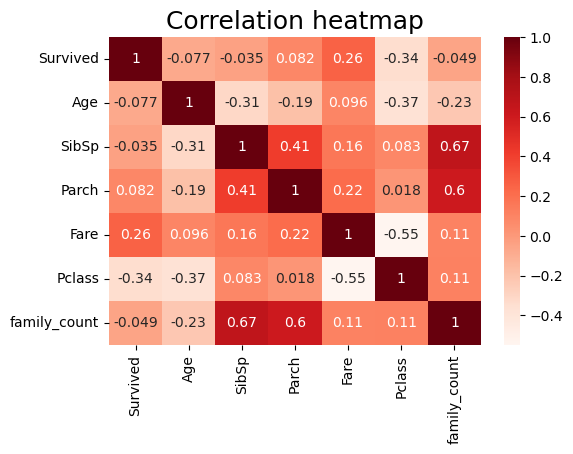

In [21]:
# Create correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df_all.corr(method='pearson'), annot=True, cmap='Reds')
plt.title('Correlation heatmap',
          fontsize=18)
plt.show()

### Observations
Corelation summary of features with 'Survived' columns as follows:
Gender_female shows highest postive correlation of 0.54, followed by Pclass showing a negative correlation of -0.34
Also 'Parch' 0.26.

Co-variants:
'Parch' (Has parent or child) and 'SibSp' (has Sibling or Spouse) correlation of 0.41 showing a family orientation to the data.
'SibSp' and Age: negative correlation of -0.31
'Pclass' and 'Age' having a negative correlation of -0.37 with higher ages associated with higher classes (1 being the highest, hence negative correlation)


In [22]:
df_all_corr = df_all.corr().abs().unstack().sort_values(kind="quicksort", ascending=False).reset_index()
df_all_corr.rename(columns={"level_0": "Feature 1", "level_1": "Feature 2", 0: 'Correlation Coefficient'}, inplace=True)
df_all_corr[df_all_corr['Feature 1'] == 'Age']

#Correlations > 0.2
df_all_corr[(df_all_corr['Correlation Coefficient'] > 0.2) & (df_all_corr['Correlation Coefficient'] != 1)]

,Feature 1,Feature 2,Correlation Coefficient
7,SibSp,family_count,0.67
8,family_count,SibSp,0.67
9,family_count,Parch,0.60
10,Parch,family_count,0.60
11,Fare,Pclass,0.55
12,Pclass,Fare,0.55
13,Parch,SibSp,0.41
14,SibSp,Parch,0.41
15,Age,Pclass,0.37
16,Pclass,Age,0.37


# Modelling

### Split the data into X and y groups

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as metrics


y = df['Survived']
X = df[['Pclass', 'Gender_male', 'Embarked_C', 'Age_Imputed', 'Single', 'Child', 'Old_Man', 'family_count']]
#, 'Age_Imputed', , 'Parch',  'Gender_female', 'Cabin_Survival_Rate', 'Embarked_C', 'Embarked_Q','Embarked_S'

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train

,Pclass,Gender_male,Embarked_C,Age_Imputed,Single,Child,Old_Man,family_count
331,1,True,False,45.5,1.0,0.0,1.0,1
733,2,True,False,23.0,1.0,0.0,0.0,1
382,3,True,False,32.0,1.0,0.0,0.0,1
704,3,True,False,26.0,0.0,0.0,0.0,3
813,3,False,False,6.0,0.0,1.0,0.0,9
...,...,...,...,...,...,...,...,...
106,3,False,False,21.0,1.0,0.0,0.0,1
270,1,True,False,30.0,1.0,0.0,0.0,1
860,3,True,False,41.0,0.0,0.0,1.0,3
435,1,False,False,14.0,0.0,1.0,0.0,6


### Save test to CSV

In [24]:
X_test.to_csv(r"C:\Users\Admin\Documents\GitHub\Google Course\Kaggle Titanic Competition\test_original.csv")

## Bayes

Accuracy: 0.799
Precision: 0.726
Recall: 0.824
F1 Score: 0.772


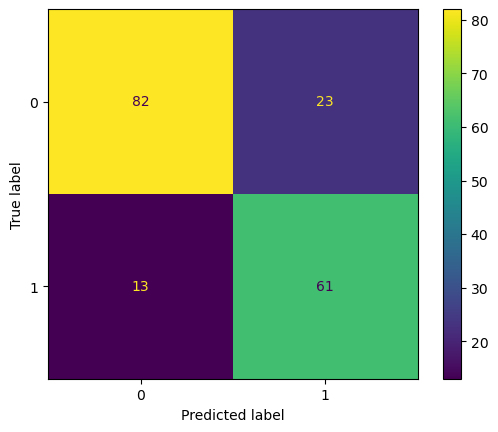

In [25]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train, y_train)
# Get the predictions on test data
y_nb_preds = gnb.predict(X_test)

#Get the Model Accuracy Metrics
print('Accuracy:', '%.3f' % accuracy_score(y_test, y_nb_preds))
print('Precision:', '%.3f' % precision_score(y_test, y_nb_preds))
print('Recall:', '%.3f' % recall_score(y_test, y_nb_preds))
print('F1 Score:', '%.3f' % f1_score(y_test, y_nb_preds))

#Predict and compare results
#dt_pred = dt.predict(X_test)
#rf_pred = rf.predict(X_test)


# Calculate the values for each quadrant in the confusion matrix
cm = metrics.confusion_matrix(y_test, y_nb_preds, labels = gnb.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = gnb.classes_)
disp.plot()

## Logistic Regression

Accuracy: 0.798883
Precision: 0.771429
Recall: 0.729730
F1 Score: 0.750000


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


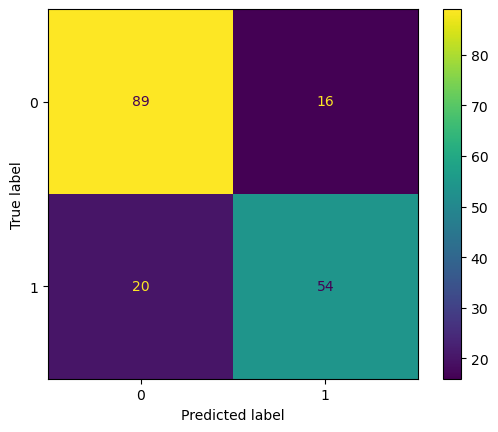

In [26]:
from sklearn.linear_model import LogisticRegression
import sklearn.metrics as metrics


clf = LogisticRegression().fit(X_train,y_train)
y_lr_preds = clf.predict(X_test)


print("Accuracy:", "%.6f" % metrics.accuracy_score(y_test, y_lr_preds))
print("Precision:", "%.6f" % metrics.precision_score(y_test, y_lr_preds))
print("Recall:", "%.6f" % metrics.recall_score(y_test, y_lr_preds))
print("F1 Score:", "%.6f" % metrics.f1_score(y_test, y_lr_preds))

# Calculate the values for each quadrant in the confusion matrix
cm = metrics.confusion_matrix(y_test, y_lr_preds, labels = clf.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = clf.classes_)
disp.plot()

## Decision Tree

In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score


decision_tree = DecisionTreeClassifier(random_state=0)
decision_tree.fit(X_train, y_train)
# Make predictions on test data
y_dt_preds = decision_tree.predict(X_test)

# Generate performance metrics
print("Accuracy:", "%.3f" % accuracy_score(y_test, y_dt_preds))
print("Precision:", "%.3f" % precision_score(y_test, y_dt_preds))
print("Recall:", "%.3f" % recall_score(y_test, y_dt_preds))
print("F1 Score:", "%.3f" % f1_score(y_test, y_dt_preds))

#cm = metrics.confusion_matrix(y_test, y_dt_preds, labels = clf.classes_)
#disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = clf.classes_)
#disp.plot()




Accuracy: 0.844
Precision: 0.848
Recall: 0.757
F1 Score: 0.800


## Random Forests

In [28]:
%%time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

# 1. Instantiate the random forest classifier
rf = RandomForestClassifier(random_state=0)

# 2. Create a dictionary of hyperparameters to tune 
cv_params = {
    'max_depth': [2, 3, 4, None],
    'max_features': [2, 3],
    'min_samples_leaf': [1, 2],
    'min_samples_split': [2, 3],
    'n_estimators': [100, 300]
}

# 3. Define a set of scoring metrics to capture
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

# 4. Instantiate the GridSearchCV object
rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=3, refit='accuracy')

# 5. Fit the GridSearcestobest
rf_cv.fit(X_train, y_train)

# 6. Evaluate the best model on the test set
rf_best_model = rf_cv.best_estimator_
rf_preds = rf_best_model.predict(X_test)

# Generate performance metrics
print("Accuracy:", "%.3f" % accuracy_score(y_test, rf_preds))
print("Precision:", "%.3f" % precision_score(y_test, rf_preds))
print("Recall:", "%.3f" % recall_score(y_test, rf_preds))
print("F1 Score:", "%.3f" % f1_score(y_test, rf_preds))


Accuracy: 0.827
Precision: 0.841
Recall: 0.716
F1 Score: 0.774
CPU times: total: 1min 56s
Wall time: 2min 13s


In [29]:
rf_cv.best_params_

{'max_depth': 4,
 'max_features': 3,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 300}

In [30]:
#Use best parameters to run model
rf_opt = RandomForestClassifier(max_depth = 4, max_features=4, min_samples_leaf = 2, min_samples_split = 2, n_estimators = 300)
                                
# 5. Fit the GridSearchCV object
rf_opt.fit(X_train, y_train)

#Get Predictions on test data
rf_opt_preds = rf_opt.predict(X_test) #use best estimator

# Generate performance metrics
print("Accuracy:", "%.3f" % accuracy_score(y_test, rf_opt_preds))
print("Precision:", "%.3f" % precision_score(y_test, rf_opt_preds))
print("Recall:", "%.3f" % recall_score(y_test, rf_opt_preds))
print("F1 Score:", "%.3f" % f1_score(y_test, rf_opt_preds))

#cm = metrics.confusion_matrix(y_test, rf_cv_preds, labels = clf.classes_)
#disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = clf.classes_)
#disp.plot()

Accuracy: 0.838
Precision: 0.869
Recall: 0.716
F1 Score: 0.785


In [31]:
X_train.to_csv(r"C:\Users\Admin\Documents\GitHub\Google Course\Kaggle Titanic Competition\check_X_train.csv")


## XGBoost

In [32]:
%%time
import xgboost as xgboost
from xgboost import XGBClassifier
from xgboost import plot_importance
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay


# 1. Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state=0) 

# 2. Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [3, 5, None], 
             'min_child_weight': [1, 2],
             'learning_rate': [0.1, 0.2, 0.3],
             'n_estimators': [100, 250]
             }    

# 3. Define a set of scoring metrics to capture
scoring2 = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

# 4. Instantiate the GridSearchCV object
xgb_cv = GridSearchCV(xgb, cv_params, scoring=scoring2, cv=3, refit='accuracy', error_score='raise')

#fit the model
xgb_cv.fit(X_train, y_train)

# 6. Evaluate the best model on the test set
xgb_best_model = xgb_cv.best_estimator_
xgb_cv_preds = xgb_best_model.predict(X_test)

# Generate performance metrics
print("Accuracy:", "%.3f" % accuracy_score(y_test, xgb_cv_preds))
print("Precision:", "%.3f" % precision_score(y_test, xgb_cv_preds))
print("Recall:", "%.3f" % recall_score(y_test, xgb_cv_preds))
print("F1 Score:", "%.3f" % f1_score(y_test, xgb_cv_preds))

#cm = metrics.confusion_matrix(y_test, xgb_cv_preds, labels = clf.classes_)
#disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = clf.classes_)
#disp.plot()



Accuracy: 0.827
Precision: 0.841
Recall: 0.716
F1 Score: 0.774
CPU times: total: 3min 38s
Wall time: 33.2 s


## Support Vector Machines

Accuracy: 0.777
Precision: 0.736
Recall: 0.716
F1 Score: 0.726


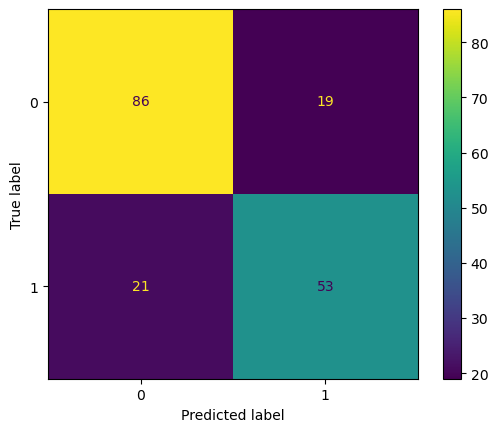

In [33]:
clf = svm.SVC(class_weight='balanced')
clf.fit(X, y)
svm_preds = clf.predict(X_test)


# Generate performance metrics
print("Accuracy:", "%.3f" % accuracy_score(y_test, svm_preds))
print("Precision:", "%.3f" % precision_score(y_test, svm_preds))
print("Recall:", "%.3f" % recall_score(y_test, svm_preds))
print("F1 Score:", "%.3f" % f1_score(y_test, svm_preds))

# Calculate the values for each quadrant in the confusion matrix
cm = metrics.confusion_matrix(y_test, svm_preds, labels = clf.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = clf.classes_)
disp.plot()

# Neural Network: MLP

# Methods to improve
1. Use scaling
2. Change network architecture - e.g. increase number of layers/nodes
   Try different types of layers.
3. Add drop-out layers to prevent overfitting
4. Try different batch sizes and epochs
5. Adjust the learning rate
6. User early stopping to avoid over fitting
7. Cross-Validation
8. User hyper parameter tuning with grid search or random search

C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.5749 - loss: 1.4837 - val_accuracy: 0.6503 - val_loss: 0.6630
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6463 - loss: 0.6663 - val_accuracy: 0.6434 - val_loss: 0.6000
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6470 - loss: 0.6118 - val_accuracy: 0.6643 - val_loss: 0.5699
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6749 - loss: 0.5785 - val_accuracy: 0.6643 - val_loss: 0.5632
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6958 - loss: 0.5777 - val_accuracy: 0.7063 - val_loss: 0.5343
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7557 - loss: 0.5496 - val_accuracy: 0.7762 - val_loss: 0.5601
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7755 - loss: 0.5417 - val_accuracy: 0.7622 - val_loss: 0.5018
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7912 - loss: 0.5183 - val_accuracy: 0.7692 - 

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8141 - loss: 0.4431 - val_accuracy: 0.7902 - val_loss: 0.5214
Epoch 52/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8098 - loss: 0.4237 - val_accuracy: 0.8322 - val_loss: 0.4585
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Accuracy: 0.782
Precision: 0.781
Recall: 0.782
F1 Score: 0.780


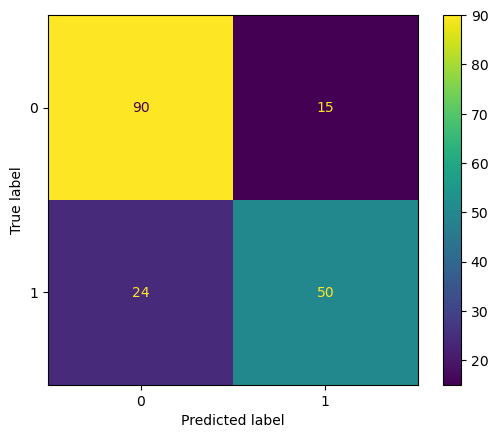

In [34]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

# Ensure X and y are defined, and if not, generate some dummy data for the sake of the example
# X, y = ...

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# One-hot encode the labels
num_classes = len(np.unique(y))
y_train_encoded = to_categorical(y_train, num_classes)
y_test_encoded = to_categorical(y_test, num_classes)
                                
                                
# Define the neural network model :  ReLU (Rectified Linear Unit)
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))  # Input layer 64 neurons, X_train_shape[1] number of features
model.add(Dense(32, activation='relu'))  # Hidden layer 32 neurons and ReLU
model.add(Dense(num_classes, activation='softmax'))  # Output layer num_classes is number of unique classes in y. 
#The activation function used for this layer is Softmax, which is typically used for multi-class classification problems.

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


# Train the model
#model.fit(X_train, y_train_encoded, epochs=50, batch_size=10, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model.fit(X_train, y_train_encoded, validation_split=0.2, epochs=100, batch_size=32, callbacks=[early_stopping], verbose=1)


# Make predictions
nn_preds_prob = model.predict(X_test)
nn_preds = np.argmax(nn_preds_prob, axis=1)

# Generate performance metrics
print("Accuracy:", "%.3f" % accuracy_score(y_test, nn_preds))
print("Precision:", "%.3f" % precision_score(y_test, nn_preds, average='weighted'))
print("Recall:", "%.3f" % recall_score(y_test, nn_preds, average='weighted'))
print("F1 Score:", "%.3f" % f1_score(y_test, nn_preds, average='weighted'))

# Calculate the values for each quadrant in the confusion matrix
cm = confusion_matrix(y_test, nn_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot()


## Gridsearch MLP

In [37]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler

# Ensure X and y are defined
# X, y = ...

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# One-hot encode the labels
num_classes = len(np.unique(y))
y_train_encoded = to_categorical(y_train, num_classes)
y_test_encoded = to_categorical(y_test, num_classes)

# Define the model creation function
def create_model(neurons=64, learning_rate=0.001):
    model = Sequential()
    model.add(Dense(neurons, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

# Set up the KerasClassifier using scikeras
model = KerasClassifier(
    model=create_model, 
    verbose=0, 
    epochs=50, 
    batch_size=10,
    optimizer=Adam,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Define the parameter grid
param_grid = {
    'model__neurons': [32, 64, 128],
    'model__learning_rate': [0.001, 0.01, 0.1],
    'batch_size': [10, 20, 30],
    'epochs': [50, 100]
}

# Perform grid search
grid = GridSearchCV(estimator=model, param_grid=param_grid, n_jobs=-1, cv=3)
grid_result = grid.fit(X_train, y_train_encoded)

# Print the best parameters and results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))


C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best: 0.825846 using {'batch_size': 20, 'epochs': 100, 'model__learning_rate': 0.001, 'model__neurons': 32}


## Optimized MLP Model

Epoch 1/100


C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.4115 - loss: 0.8228 - val_accuracy: 0.5385 - val_loss: 0.7102
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6688 - loss: 0.6469 - val_accuracy: 0.7762 - val_loss: 0.5904
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8024 - loss: 0.5540 - val_accuracy: 0.7972 - val_loss: 0.5169
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7724 - loss: 0.5302 - val_accuracy: 0.8042 - val_loss: 0.4722
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8015 - loss: 0.4758 - val_accuracy: 0.8112 - val_loss: 0.4457
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7958 - loss: 0.4684 - val_accuracy: 0.8112 - val_loss: 0.4339
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7727 - loss: 0.4939 - val_accuracy: 0.8112 - val_loss: 0.4233
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8197 - loss: 0.4263 - val_accuracy: 0.8112 - val_loss: 0.

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8336 - loss: 0.3798 - val_accuracy: 0.8322 - val_loss: 0.4102
Epoch 52/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8272 - loss: 0.3762 - val_accuracy: 0.8252 - val_loss: 0.4173
Epoch 53/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8502 - loss: 0.3356 - val_accuracy: 0.8182 - val_loss: 0.4156
Epoch 54/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8458 - loss: 0.3569 - val_accuracy: 0.8322 - val_loss: 0.4173
Epoch 55/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8445 - loss: 0.3664 - val_accuracy: 0.8112 - val_loss: 0.4127
Epoch 56/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8537 - loss: 0.3566 - val_accuracy: 0.8252 - val_loss: 0.4189
Epoch 57/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8312 - loss: 0.3938 - val_accuracy: 0.8182 - val_loss: 0.4157
Epoch 58/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8457 - loss: 0.3614 - val_accuracy: 0.8252 - val_lo

Accuracy: 0.810
Precision: 0.810
Recall: 0.810
F1 Score: 0.808


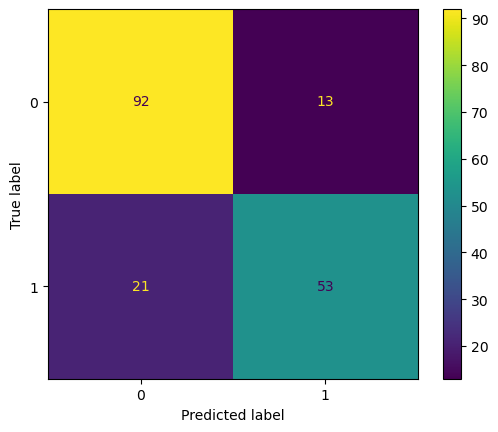

In [49]:
# Define the model creation function
#Note cross-validation is part of GridSearchCV which gave us the optimized parameters, so we don't need to run CV again.
from tensorflow.keras.layers import Dense, Dropout

# Define the model creation function
def create_model(neurons=32, learning_rate=0.001, dropout_rate=0.5):
    model = Sequential()
    model.add(Dense(neurons, input_dim=X_train.shape[1], activation='relu'))
  #  model.add(Dropout(dropout_rate))  # Add dropout layer
    model.add(Dense(neurons, activation='relu'))
  #  model.add(Dropout(dropout_rate))  # Add dropout layer
    model.add(Dense(num_classes, activation='softmax'))
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

# Set up the KerasClassifier using scikeras
model = KerasClassifier(
    model=create_model,
    verbose=0
)


#Fit the model
model.fit(X_train, y_train_encoded, validation_split=0.2, epochs=100, batch_size=32, verbose=1)

# Make predictions
nn_preds_prob = model.predict(X_test)
nn_preds = np.argmax(nn_preds_prob, axis=1)

# Generate performance metrics
print("Accuracy:", "%.3f" % accuracy_score(y_test, nn_preds))
print("Precision:", "%.3f" % precision_score(y_test, nn_preds, average='weighted'))
print("Recall:", "%.3f" % recall_score(y_test, nn_preds, average='weighted'))
print("F1 Score:", "%.3f" % f1_score(y_test, nn_preds, average='weighted'))

# Calculate the values for each quadrant in the confusion matrix
cm = confusion_matrix(y_test, nn_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot()


In [44]:
# Print the predictions along with the actual values
comparison_df = pd.DataFrame({
    #'PassengerID': X_test['PassengerId'],
    'Pclass': X_test['Pclass'],
    'Gender_male': X_test['Gender_male'],    
    'Actual y': y_test,
    'Naive Bayes Prediction': y_nb_preds,
    'Logistic Regression Prediction': y_lr_preds,
    'Decision Tree Prediction': y_dt_preds,
    'Random Forests Prediction': rf_preds,
    'XG Boost Prediction': xgb_cv_preds
})
comparison_df.to_csv(r"C:\Users\Admin\Documents\GitHub\Google Course\Kaggle Titanic Competition\train_test_predictions.csv")
comparison_df

,Pclass,Gender_male,Actual y,Naive Bayes Prediction,Logistic Regression Prediction,Decision Tree Prediction,Random Forests Prediction,XG Boost Prediction
709,3,True,1,1,0,1,1,1
439,2,True,0,0,0,0,0,0
840,3,True,0,0,0,0,0,0
720,2,False,1,1,1,1,1,1
39,3,False,1,1,1,0,1,1
...,...,...,...,...,...,...,...,...
433,3,True,0,0,0,0,0,0
773,3,True,0,0,0,0,0,0
25,3,False,1,1,0,0,0,0
84,2,False,1,1,1,1,1,1
